چندجمله‌ای لاگرانژ (ضرایب از درجه بالا به پایین):
       5         4         3         2
0.175 x - 2.958 x + 18.38 x - 52.04 x + 68.45 x - 31

ضابطه‌ی لاگرانژ به‌صورت نمادین:
   5       4        3         2              
7⋅x    71⋅x    147⋅x    1249⋅x    1369⋅x     
──── - ───── + ────── - ─────── + ────── - 31
 40     24       8        24        20       

اسپلاین مکعبی طبیعی ایجاد شد.

ضوابط اسپلاین در هر بازه (به‌صورت چندجمله‌ای محلی):
بازه [1.0, 2.0]: S(x) = 1.0*x**3 - 0.813397129186603*x**2 - 1.37320574162679*x + 1.0
بازه [2.0, 3.0]: S(x) = 3.0*x**3 - 16.3732057416268*x**2 + 28.933014354067*x - 15.4401913875598
بازه [3.0, 4.0]: S(x) = 5.0*x**3 - 41.6937799043062*x**2 + 117.401913875598*x - 114.507177033493
بازه [4.0, 5.0]: S(x) = 8.0*x**3 - 95.8516746411483*x**2 + 377.416267942584*x - 485.789473684211
بازه [5.0, 6.0]: S(x) = 5.0*x**3 - 78.8995215311005*x**2 + 415.344497607656*x - 729.684210526316


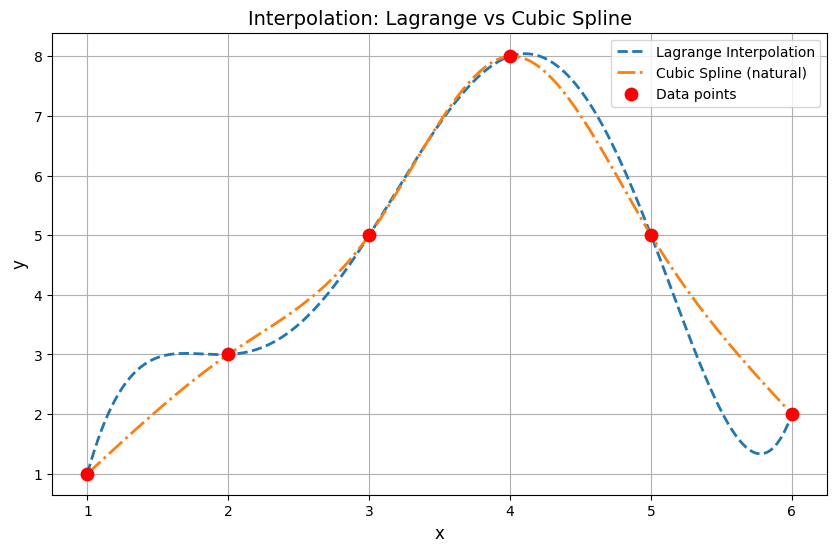

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline
import sympy as sp

x_points = np.array([1, 2, 3, 4, 5, 6])
y_points = np.array([1, 3, 5, 8, 5, 2])

#  درونیابی لاگرانژ
poly = lagrange(x_points, y_points)
print("چندجمله‌ای لاگرانژ (ضرایب از درجه بالا به پایین):")
print(poly)

# نمایش نمادین با sympy
x_sym = sp.Symbol('x')
lagrange_expr = sum(y_points[i] * sp.prod((x_sym - x_points[j]) / (x_points[i] - x_points[j])
                                           for j in range(len(x_points)) if j != i)
                    for i in range(len(x_points)))
print("\nضابطه‌ی لاگرانژ به‌صورت نمادین:")
sp.pprint(sp.expand(lagrange_expr))

#  درونیابی اسپلاین مکعبی (طبیعی)
cs = CubicSpline(x_points, y_points, bc_type='natural')
print("\nاسپلاین مکعبی طبیعی ایجاد شد.")

# استخراج ضرایب اسپلاین در هر بازه
breaks = cs.x
coeffs = cs.c.T  # هر ردیف: [a, b, c, d] برای S(x)=a + b*(x-x_i) + c*(x-x_i)^2 + d*(x-x_i)^3
print("\nضوابط اسپلاین در هر بازه (به‌صورت چندجمله‌ای محلی):")
for i in range(len(breaks)-1):
    a, b, c, d = coeffs[i]
    x_i = breaks[i]
    expr = a + b*(x_sym - x_i) + c*(x_sym - x_i)**2 + d*(x_sym - x_i)**3
    print(f"بازه [{breaks[i]:.1f}, {breaks[i+1]:.1f}]: S(x) = {sp.expand(expr)}")


x_new = np.linspace(1, 6, 200)
y_lagrange = poly(x_new)
y_spline = cs(x_new)

plt.figure(figsize=(10, 6))
plt.plot(x_new, y_lagrange, '--', label='Lagrange Interpolation', linewidth=2)
plt.plot(x_new, y_spline, '-.', label='Cubic Spline (natural)', linewidth=2)
plt.scatter(x_points, y_points, color='red', s=80, label='Data points', zorder=5)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Interpolation: Lagrange vs Cubic Spline', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [2]:
!pip install openpyxl seaborn -q

Saving پروژه 3.xlsx to پروژه 3 (4).xlsx
ستون‌های فایل: ['Run time for different data size', 'Alg.1', 'Alg.2', 'Alg.3']
نمونه داده:
   Run time for different data size  Alg.1  Alg.2  Alg.3
0                            100KB     50    200    100
1                            200KB     55    220    200
2                            300KB     60    240    300
3                            400KB     65    260    400
4                            500KB     70    280    500


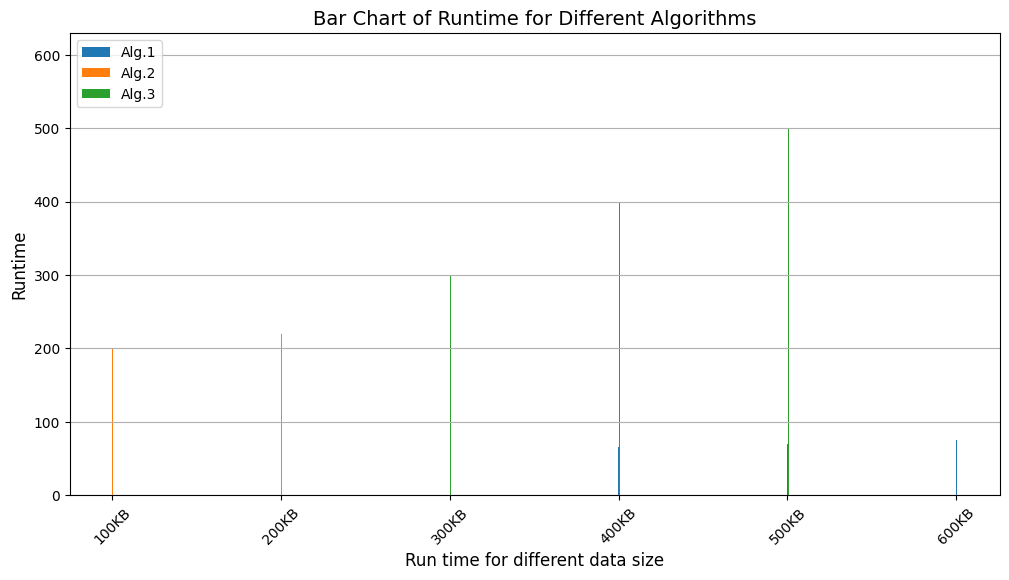

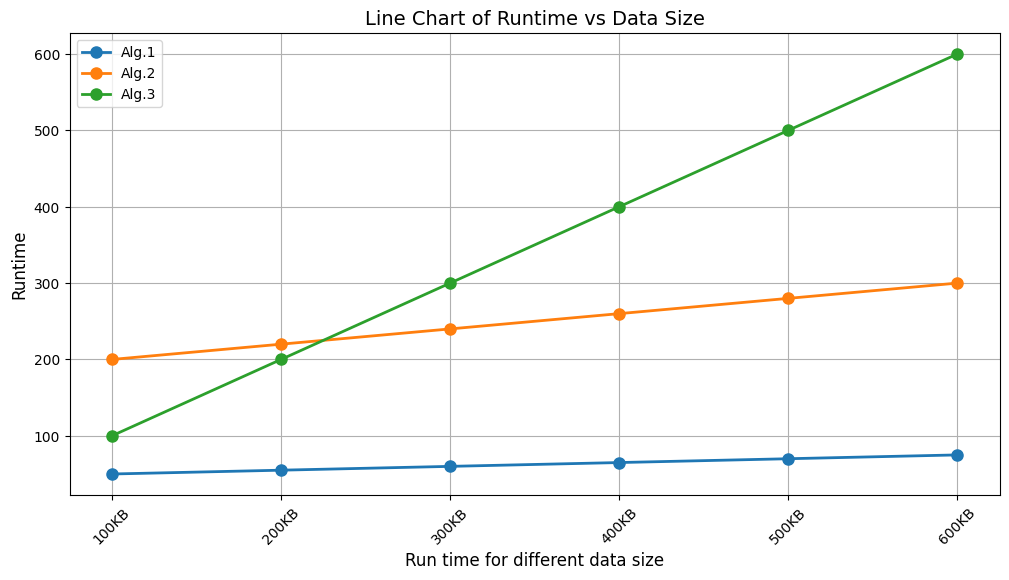

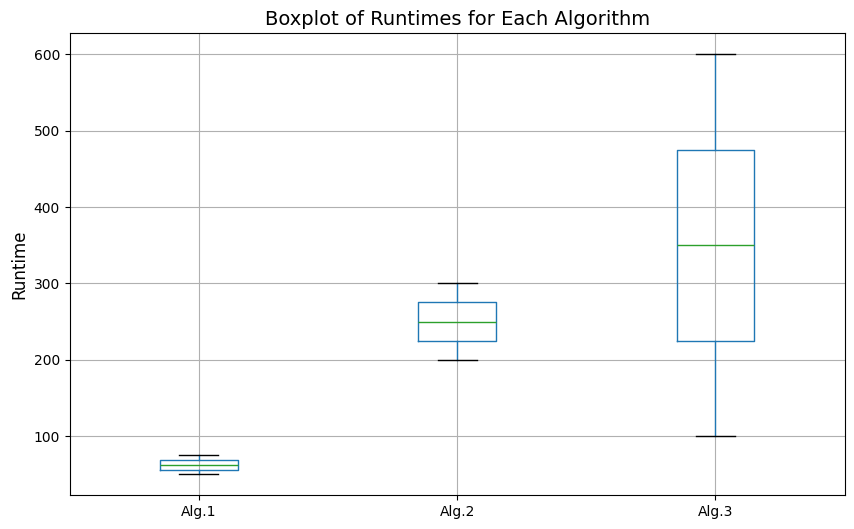


میانگین زمان اجرای الگوریتم ۲ برای داده‌های موجود: 250.00


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import re

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename, engine='openpyxl', header=0)

# پاکسازی نام ستون‌ها
df.columns = df.columns.str.strip()
print("ستون‌های فایل:", df.columns.tolist())
print("نمونه داده:\n", df.head())

data_col = df.columns[0]          # ستون اول (مثلاً 'Run time for different data size')
alg_cols = df.columns[1:4]        # سه ستون الگوریتم

# استخراج عدد از ستون اول (حذف 'KB' و تبدیل به عدد)
df['size_numeric'] = df[data_col].astype(str).str.extract(r'(\d+)').astype(float)

# تبدیل ستون‌های الگوریتم به عدد (با اجبار خطاها به NaN)
for col in alg_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# حذف ردیف‌های با داده‌ی نامعتبر
df = df.dropna(subset=list(alg_cols) + ['size_numeric'])

# مرتب‌سازی بر اساس اندازه
df = df.sort_values('size_numeric').reset_index(drop=True)

# مقادیر عددی و برچسب‌ها
x_num = df['size_numeric'].values
x_labels = df[data_col].astype(str).str.strip().values  # برچسب‌های اصلی (مثلاً '100KB')

#  رسم نمودار میله‌ای گروهی
width = 0.25
plt.figure(figsize=(12, 6))
for i, alg in enumerate(alg_cols):
    plt.bar(x_num + i*width, df[alg], width=width, label=alg)
plt.xlabel(data_col, fontsize=12)
plt.ylabel('Runtime', fontsize=12)
plt.title('Bar Chart of Runtime for Different Algorithms', fontsize=14)
plt.xticks(x_num, x_labels, rotation=45)
plt.legend()
plt.grid(True, axis='y')
plt.show()

#  رسم نمودار خطی
plt.figure(figsize=(12, 6))
for alg in alg_cols:
    plt.plot(x_num, df[alg], marker='o', linewidth=2, markersize=8, label=alg)
plt.xlabel(data_col, fontsize=12)
plt.ylabel('Runtime', fontsize=12)
plt.title('Line Chart of Runtime vs Data Size', fontsize=14)
plt.xticks(x_num, x_labels, rotation=45)
plt.legend()
plt.grid(True)
plt.show()

#  رسم نمودار جعبه‌ای (Boxplot)
plt.figure(figsize=(10, 6))
df[alg_cols].boxplot(grid=True)
plt.title('Boxplot of Runtimes for Each Algorithm', fontsize=14)
plt.ylabel('Runtime', fontsize=12)
plt.show()

#  میانگین الگوریتم ۲
mean_alg2 = df['Alg.2'].mean()
print(f"\nمیانگین زمان اجرای الگوریتم ۲ برای داده‌های موجود: {mean_alg2:.2f}")

In [9]:
import numpy as np
from scipy.integrate import quad
from numpy.polynomial.legendre import leggauss

def f(x):
    return np.exp(x**2)

#  انتگرال دقیق با quad (مرجع)
I_quad, err = quad(f, 0, 1)
print(f"انتگرال دقیق با quad: {I_quad:.12f}")

#  روش ذوزنقه
n_trap = 1000
x_trap = np.linspace(0, 1, n_trap+1)
y_trap = f(x_trap)
I_trap = np.trapz(y_trap, x_trap)
print(f"روش ذوزنقه (n={n_trap}): {I_trap:.12f}")

#  روش سیمسون
n_simpson = 1000
if n_simpson % 2 == 1:
    n_simpson += 1
x_sim = np.linspace(0, 1, n_simpson+1)
y_sim = f(x_sim)
h = (1 - 0) / n_simpson
I_simpson = (h/3) * (y_sim[0] + y_sim[-1] +
                     4 * sum(y_sim[1:-1:2]) +
                     2 * sum(y_sim[2:-2:2]))
print(f"روش سیمسون (n={n_simpson}): {I_simpson:.12f}")

#  روش گس-لژاندر (Gauss-Legendre)
n_gauss = 50
x_gauss, w_gauss = leggauss(n_gauss)
# تبدیل بازه [0,1] به [-1,1] : x = 0.5*(t+1)
x_trans = 0.5 * (x_gauss + 1)
I_gauss = 0.5 * np.sum(w_gauss * f(x_trans))
print(f"روش گس-لژاندر (n={n_gauss}): {I_gauss:.12f}")

#  مقایسه خطاها
print("\nمقایسه نتایج:")
print(f"quad (مرجع):          {I_quad:.12f}")
print(f"ذوزنقه:               {I_trap:.12f}  (خطای نسبی: {abs(I_trap-I_quad)/I_quad:.2e})")
print(f"سیمسون:               {I_simpson:.12f}  (خطای نسبی: {abs(I_simpson-I_quad)/I_quad:.2e})")
print(f"گس-لژاندر:            {I_gauss:.12f}  (خطای نسبی: {abs(I_gauss-I_quad)/I_quad:.2e})")

انتگرال دقیق با quad: 1.462651745907
روش ذوزنقه (n=1000): 1.462652198954
روش سیمسون (n=1000): 1.462651745907
روش گس-لژاندر (n=50): 1.462651745907

مقایسه نتایج:
quad (مرجع):          1.462651745907
ذوزنقه:               1.462652198954  (خطای نسبی: 3.10e-07)
سیمسون:               1.462651745907  (خطای نسبی: 2.06e-13)
گس-لژاندر:            1.462651745907  (خطای نسبی: 1.37e-15)


/tmp/ipykernel_1619/1269931194.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_trap = np.trapz(y_trap, x_trap)
